# 🧠 Artificial Neural Network (ANN) for Regression

In this notebook we will build an **Artificial Neural Network (ANN)** to solve a **regression problem** using **PyTorch**.

The goal is to predict **power plant energy output** using environmental features.

This notebook covers the complete deep learning workflow:

- Loading dataset
- Preprocessing data
- Building ANN model
- Training the model
- Evaluating model performance

This example demonstrates how **neural networks can be used for regression tasks**.

## 📊 Dataset

We use the **Combined Cycle Power Plant Dataset**.

### Input Features

- **AT** → Temperature  
- **V** → Exhaust Vacuum  
- **AP** → Ambient Pressure  
- **RH** → Relative Humidity  

### Target Variable

- **PE** → Energy Output

### Problem Type
- **Regression**

The neural network will learn a mapping from **input features → power output**.

## Step 1: Import Required Libraries

We import the libraries required for:

- data processing
- neural network training
- evaluation

In [1]:
# PyTorch library for building neural networks
import torch
import torch.nn as nn

# Data handling
import pandas as pd
import numpy as np

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Visualization
import matplotlib.pyplot as plt

## Step 2: Load Dataset

Now we load the **Power Plant dataset** into a pandas DataFrame.

In [2]:
# Load dataset
df = pd.read_csv("../../datasets/powerplant_dataset.csv")

# Display first 5 rows
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


## Step 3: Separate Features and Target

We divide the dataset into:

- **X → input features**
- **y → target variable**

In [3]:
# Features (input variables)
X = df.drop("PE", axis=1)

# Target variable
y = df["PE"]

## Step 4: Train-Test Split

We split the dataset into:

- **Training set**
- **Testing set**

Training data is used to train the model, while test data evaluates performance.

In [4]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 5: Feature Scaling

Neural networks perform better when input features are **scaled**.

We use **StandardScaler** to normalize the data.

In [5]:
# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

## Step 6: Convert Data to PyTorch Tensors

PyTorch models require data in **tensor format**.

In [6]:
# Convert training data to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

# Convert testing data to tensors
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

## Step 7: Build the Neural Network

We create a simple **Feedforward Neural Network** with:

- Input layer
- Hidden layers
- Output layer

The output layer contains **1 neuron** since this is a regression problem.

In [7]:
# Define neural network architecture
class ANNModel(nn.Module):
    
    def __init__(self):
        super(ANNModel, self).__init__()
        
        # Define layers
        self.layer1 = nn.Linear(4, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)
        
        # Activation function
        self.relu = nn.ReLU()
    
    def forward(self, x):
        
        # Forward pass through network
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        
        return x

# Initialize model
model = ANNModel()

print(model)

ANNModel(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


## Step 8: Define Loss Function and Optimizer

For regression problems we commonly use:

**Loss Function**
- Mean Squared Error (MSE)


**Optimizer**
- Adam Optimizer

In [8]:
# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Step 9: Train the Neural Network

Now we train the neural network by repeatedly:

1. Forward propagation  
2. Compute loss  
3. Backpropagation  
4. Update weights

In [9]:
# Number of training epochs
epochs = 100

# Store loss values
loss_history = []

for epoch in range(epochs):
    
    # Forward pass
    predictions = model(X_train)
    
    # Compute loss
    loss = criterion(predictions, y_train)
    
    # Clear previous gradients
    optimizer.zero_grad()
    
    # Backpropagation
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    # Store loss
    loss_history.append(loss.item())
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 206461.4844
Epoch [20/100], Loss: 206383.6875
Epoch [30/100], Loss: 206296.1250
Epoch [40/100], Loss: 206196.2969
Epoch [50/100], Loss: 206080.4844
Epoch [60/100], Loss: 205944.6094
Epoch [70/100], Loss: 205783.7500
Epoch [80/100], Loss: 205592.6875
Epoch [90/100], Loss: 205366.0469
Epoch [100/100], Loss: 205097.2344


## Step 10: Evaluate Model Performance

Now we evaluate the model using the **test dataset**.

In [10]:
# Disable gradient tracking for evaluation
with torch.no_grad():
    
    predictions = model(X_test)
    
    # Convert tensors to numpy
    predictions = predictions.numpy()
    actual = y_test.numpy()

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("RMSE:", rmse)

RMSE: 452.6488187601951


## Step 11: Visualize Training Loss

Plot training loss to observe how the model improves during training.

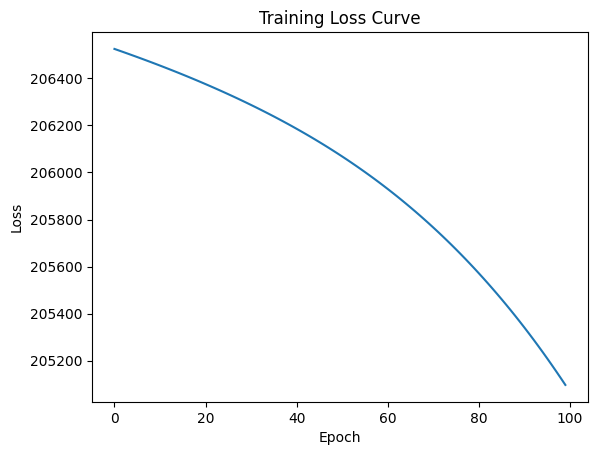

In [11]:
# Plot training loss
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## 🎯 Conclusion

In this notebook we:

- Built an **ANN for regression**
- Trained the model using **PyTorch**
- Evaluated model performance using **RMSE**

Artificial Neural Networks can learn complex relationships between input variables and continuous outputs, making them useful for many regression tasks.